## Tarea 5

### Sección 3

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [5]:
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target # 0 = Benigno, 1 = Maligno
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

#### Sección 3.1

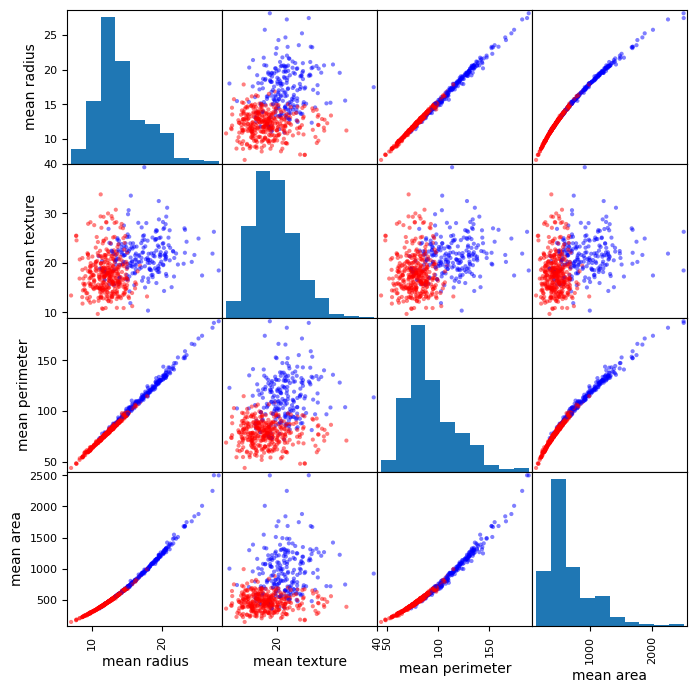

In [6]:
# from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df.iloc[:, :4], c=df['target'], cmap='bwr', figsize=(8,8))
plt.show()

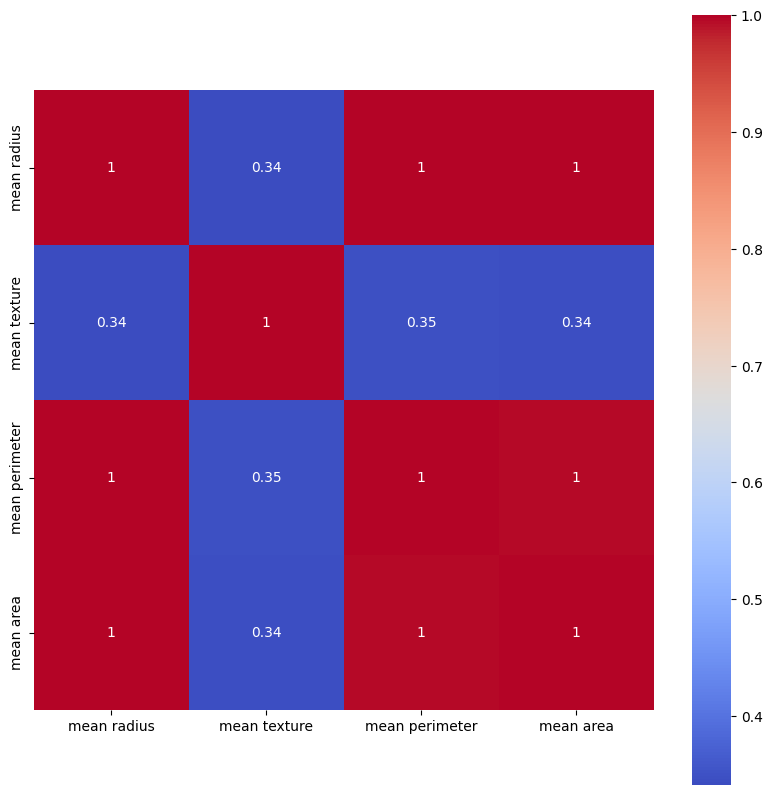

In [7]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(df.iloc[:, 0:4].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.show()

#### Sección 3.2

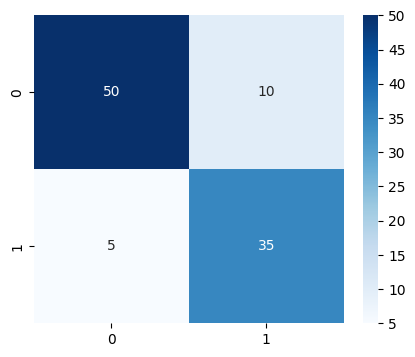

In [8]:
cm = [[50, 10], [5, 35]]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

#### Sección 3.4

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df['target'], df['prediction'])
precision = precision_score(df['target'], df['prediction'])
recall = recall_score(df['target'], df['prediction'])
f1 = f1_score(df['target'], df['prediction'])
```

#### Sección 3.4

##### 3.4.1
Seleccionar __tres__ variables del conjunto con diferente correlación con el diagnóstico: una de alta correlación, una de correlación media y una de baja correlación. Para ello calcula la matriz de correlación y ordena los valores en orden descendente. Puedes usar `df.corr()[['target']]` para obtener la correlación de todas las variables con el diagnóstico (target).

En `df_correlacion` guardamos el DataFrame de la correlación de todas las variables con `target`. Después de ordenarlas de forma descendente consideramos todas las filas excepto la primera `[1:]`, pues la primera corresponde a la correlación de _target_ con _target_.

Nótese que se ordenan los valores en valor absoluto.

In [37]:
df_correlacion = df.corr()[['target']].sort_values(by='target', key=lambda x: abs(x), ascending=False)[1:]

# Variable con alta correlación
alta_corr = df_correlacion.iloc[0]

# Variable con media correlación (tomamos la décima variable solo por tomar alguna variable entre la alta y baja correlación)
media_corr = df_correlacion.iloc[10]

# Variable con baja correlación
baja_corr = df_correlacion.iloc[-1]

print(f'''
Variable con alta correlación: {alta_corr.name}
Variable con media correlación: {media_corr.name}
Variable con baja correlación: {baja_corr.name}
''')


Variable con alta correlación: worst concave points
Variable con media correlación: mean compactness
Variable con baja correlación: symmetry error



##### 3.4.2
Estudia las tres variables, puedes usar `df['VARIABLE'].describe()` para analizar su distribución y valores estadísticos.

Sin considerar distinción en el target

In [ ]:
df[[alta_corr.name, media_corr.name, baja_corr.name]].describe()

,worst concave points,mean compactness,symmetry error
count,569.000000,569.000000,569.000000
mean,0.114606,0.104341,0.020542
std,0.065732,0.052813,0.008266
min,0.000000,0.019380,0.007882
25%,0.064930,0.064920,0.015160
50%,0.099930,0.092630,0.018730
75%,0.161400,0.130400,0.023480
max,0.291000,0.345400,0.078950


Considerando distinción en el target

In [107]:
df.groupby("target")[[alta_corr.name]].describe()

worst concave points                                                 \
                      count      mean       std      min      25%      50%   
target                                                                       
0                     212.0  0.182237  0.046308  0.02899  0.15275  0.18200   
1                     357.0  0.074444  0.035797  0.00000  0.05104  0.07431   

                         
             75%    max  
target                   
0       0.210675  0.291  
1       0.097490  0.175

In [90]:
df.groupby("target")[[media_corr.name]].describe()

mean compactness                                                 \
                  count      mean       std      min      25%      50%   
target                                                                   
0                 212.0  0.145188  0.053987  0.04605  0.10960  0.13235   
1                 357.0  0.080085  0.033750  0.01938  0.05562  0.07529   

                         
            75%     max  
target                   
0       0.17240  0.3454  
1       0.09755  0.2239

In [91]:
df.groupby("target")[[baja_corr.name]].describe()

symmetry error                                                   \
                count      mean       std       min       25%      50%   
target                                                                   
0               212.0  0.020472  0.010065  0.007882  0.014615  0.01770   
1               357.0  0.020584  0.006999  0.009539  0.015600  0.01909   

                           
             75%      max  
target                     
0       0.022132  0.07895  
1       0.024060  0.06146

##### 3.4.3

Dibuja las variables para tumores malignos y benignos, y usa la estimación de densidad de kernel (KDE) para visualizar su distribución.

Recordemos que: 
* target = 0 es benigno
* target = 1 es maligno

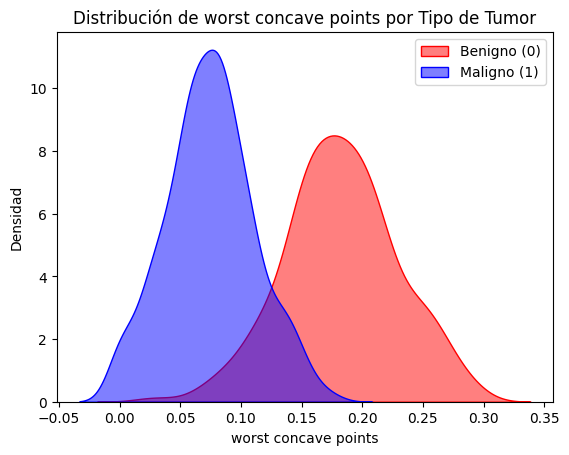

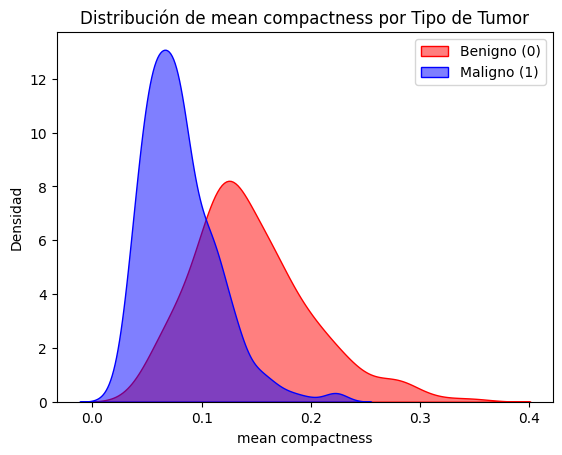

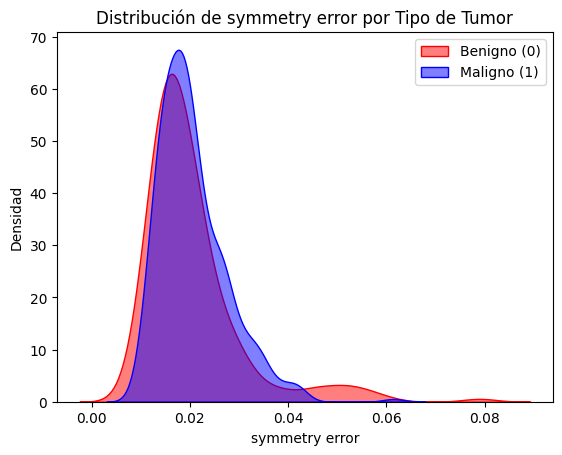

In [149]:
for name in [alta_corr.name, media_corr.name, baja_corr.name]:

    # plt.figure(figsize=(8, 5))
    sns.kdeplot(df[df['target'] == 0][name], label="Benigno (0)", fill=True, color="red", alpha=0.5)
    sns.kdeplot(df[df['target'] == 1][name], label="Maligno (1)", fill=True, color="blue", alpha=0.5)
    plt.xlabel(name)
    plt.ylabel("Densidad")
    plt.title("Distribución de " + name + " por Tipo de Tumor")
    plt.legend()
    plt.show()

In [133]:
df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


`DataFrame.astype(int)` para convertir booleano a entero:
* `int(False) -> 0`
* `int(True) -> 1`  

In [134]:
umbral = 0.12

df['prediccion'] = (df['worst concave points'] < umbral).astype(int)  # 0: benigno, 1:maligno

In [135]:
FP = df[(df['target']==0) & (df['prediccion']==1)]

FN = df[(df['target']==1) & (df['prediccion']==0)]

In [136]:
print(FP[['worst concave points', 'target', 'prediccion']])

FP.shape[0]

     worst concave points  target  prediccion
10                0.09975       0           1
13                0.11190       0           1
38                0.02899       0           1
40                0.11120       0           1
100               0.11840       0           1
119               0.11850       0           1
135               0.09331       0           1
171               0.11600       0           1
197               0.09181       0           1
207               0.10960       0           1
213               0.10990       0           1
261               0.08235       0           1
263               0.08568       0           1
274               0.11360       0           1
297               0.07160       0           1
329               0.10470       0           1
414               0.06575       0           1
489               0.08737       0           1
514               0.11200       0           1


19

Ejercicio 11 son 3 gráficas